<a href="https://colab.research.google.com/github/MettaSurendhar/squad_chatbot/blob/main/squad_chatbot_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Question Answering Chatbot using DistilBERT and SQuAD**

Build a **Question Answering chatbot** using the **SQuAD dataset** and **Hugging Face Transformers**.  

Demonstrated in two approaches:
1. **Fine-tuning DistilBERT** (`distilbert-base-uncased`) using the open dataset SQuAD for basic question-answering model.
2. Using a **pre-trained model** (`distilbert-base-uncased-distilled-squad`) on the SQuAD dataset to integrated it into a **Streamlit web app** for interactive usage.


In [1]:
! pip install datasets transformers torch evaluate huggingface_hub[hf_xet] transformers[torch]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.5 MB/s eta 0:00:00


In [15]:
from datasets import load_dataset
from transformers import AutoTokenizer, DefaultDataCollator, AutoModelForQuestionAnswering, TrainingArguments, Trainer, pipeline

---
## Load Dataset
- Used the **SQuAD v1** dataset from Hugging Face `datasets` library.  
- Used only 5000 samples and split into train/test.


In [3]:
squad = load_dataset("squad", split="train[:5000]")
squad = squad.train_test_split(test_size=0.2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

In [4]:
squad["train"][0]

{'id': '5733fb934776f41900661639',
 'title': 'Genocide',
 'context': 'Barbara Harff and Ted Gurr defined genocide as "the promotion and execution of policies by a state or its agents which result in the deaths of a substantial portion of a group ...[when] the victimized groups are defined primarily in terms of their communal characteristics, i.e., ethnicity, religion or nationality." Harff and Gurr also differentiate between genocides and politicides by the characteristics by which members of a group are identified by the state. In genocides, the victimized groups are defined primarily in terms of their communal characteristics, i.e., ethnicity, religion or nationality. In politicides the victim groups are defined primarily in terms of their hierarchical position or political opposition to the regime and dominant groups. Daniel D. Polsby and Don B. Kates, Jr. state that "... we follow Harff\'s distinction between genocides and \'pogroms,\' which she describes as \'short-lived outbursts

---
## Preprocess

Before finetuning, pre-processing the dataset

- Each **question-context pair** is tokenized into model-readable format.
  - **Tokenizer** converts question and context text into token IDs using `distilbert-base-uncased`.
  - **Truncate** only the second sequence (context) if too long.
  - **Offset Mapping** keeps track of how tokens map to original text characters.
- Map the answer span (start and end positions) from the raw text to token indices.
  - Extracts `start_char` and `end_char` from dataset.
  - Finds which tokens correspond to that character range.
  - Stores `start_positions` and `end_positions` (used as labels).

In [5]:
tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:
def preprocess_function(examples):
    questions = [q.strip() for q in examples["question"]]
    inputs = tokenizer(
        questions,
        examples["context"],
        max_length=384,
        truncation="only_second",
        return_offsets_mapping=True,
        padding="max_length",
    )

    offset_mapping = inputs.pop("offset_mapping")
    answers = examples["answers"]
    start_positions = []
    end_positions = []

    for i, offset in enumerate(offset_mapping):
        answer = answers[i]
        start_char = answer["answer_start"][0]
        end_char = answer["answer_start"][0] + len(answer["text"][0])
        sequence_ids = inputs.sequence_ids(i)

        # Find the start and end of the context
        idx = 0
        while sequence_ids[idx] != 1:
            idx += 1
        context_start = idx
        while sequence_ids[idx] == 1:
            idx += 1
        context_end = idx - 1

        # If the answer is not fully inside the context, label it (0, 0)
        if offset[context_start][0] > end_char or offset[context_end][1] < start_char:
            start_positions.append(0)
            end_positions.append(0)
        else:
            # Otherwise it's the start and end token positions
            idx = context_start
            while idx <= context_end and offset[idx][0] <= start_char:
                idx += 1
            start_positions.append(idx - 1)

            idx = context_end
            while idx >= context_start and offset[idx][1] >= end_char:
                idx -= 1
            end_positions.append(idx + 1)

    inputs["start_positions"] = start_positions
    inputs["end_positions"] = end_positions
    return inputs

In [7]:
tokenized_squad = squad.map(preprocess_function, batched=True, remove_columns=squad["train"].column_names)

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [8]:
data_collator = DefaultDataCollator()

---
## Fine-tuning DistilBERT
- Fine-tuning the `distilbert-base-uncased` model for 3 epochs using the Hugging Face `Trainer` API.
- **Trainer** handles training, evaluation, batching, and logging automatically.
- **Data Collator** dynamically pads sequences in a batch for efficiency.

In [9]:
model = AutoModelForQuestionAnswering.from_pretrained("distilbert/distilbert-base-uncased")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForQuestionAnswering were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
training_args = TrainingArguments(
    output_dir="my_awesome_qa_model",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    push_to_hub=False,
    dataloader_pin_memory=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_squad["train"],
    eval_dataset=tokenized_squad["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,No log,2.350385
2,2.681300,1.701555
3,2.681300,1.647079


TrainOutput(global_step=750, training_loss=2.2490770263671873, metrics={'train_runtime': 29973.0521, 'train_samples_per_second': 0.4, 'train_steps_per_second': 0.025, 'total_flos': 1175877900288000.0, 'train_loss': 2.2490770263671873, 'epoch': 3.0})

---
## Evaluate Model

- Use pipeline - `question-answering` for easy inference.
- Provide question and context then get predicted answer with confidence.
- Verifing model’s ability to locate correct answer spans.

In [25]:
question = "How many programming languages does BLOOM support?"
context = "BLOOM has 176 billion parameters and can generate text in 46 languages natural languages and 13 programming languages."

# Load the fine-tuned model and tokenizer from the latest checkpoint directory
loaded_model = AutoModelForQuestionAnswering.from_pretrained("./my_awesome_qa_model/checkpoint-750")
loaded_tokenizer = AutoTokenizer.from_pretrained("./my_awesome_qa_model/checkpoint-750")

# Create the pipeline using the loaded model and tokenizer
question_answerer = pipeline("question-answering", model=loaded_model, tokenizer=loaded_tokenizer)

# Use the pipeline to answer the question
answer = question_answerer(question=question, context=context)
print(answer)

Device set to use cpu


{'score': 0.13472501933574677, 'start': 10, 'end': 21, 'answer': '176 billion'}


In [26]:
samples = [
    {
        "question": "Who developed BLOOM?",
        "context": "BLOOM was developed by Hugging Face and over 1000 AI researchers.",
    },
    {
        "question": "How many natural languages does BLOOM support?",
        "context": "BLOOM can generate text in 46 natural languages and 13 programming languages.",
    },
]

for s in samples:
    print("Q:", s["question"])
    print("A:", question_answerer(question=s["question"], context=s["context"])["answer"])
    print("-" * 50)

Q: Who developed BLOOM?
A: Hugging Face and over 1000
--------------------------------------------------
Q: How many natural languages does BLOOM support?
A: 46 natural languages and 13
--------------------------------------------------


In [27]:
metrics = trainer.evaluate()
print(metrics)

{'eval_loss': 1.647079348564148, 'eval_runtime': 753.1651, 'eval_samples_per_second': 1.328, 'eval_steps_per_second': 0.084, 'epoch': 3.0}


---
## Streamlit Web App

To make the question-answering chatbot interactive, developed and deployed in streamlit web app.

- Features:
  - Users can select sample contexts from the SQuAD dataset or input their own custom context.
  - Enter a question, and the app returns the predicted answer using the pre-trained DistilBERT model.
  - Clean, responsive interface with highlighted answer section.

- Deployment:
  - The app is hosted on Streamlit Community Cloud.
  - Live Demo: https://squad-chatbot.streamlit.app
  - Source Code: https://github.com/MettaSurendhar/squad_chatbot

- How to Run Locally:
  - Clone the repository
    ```
    git clone https://github.com/MettaSurendhar/squad_chatbot.git
    cd squad_chatbot
    ```
  - Install dependencies
    ```
    pip install -r requirements.txt
    ```
  - Run the Streamlit app
    ```
    streamlit run qa_app.py
    ```

- ScreenShots:

    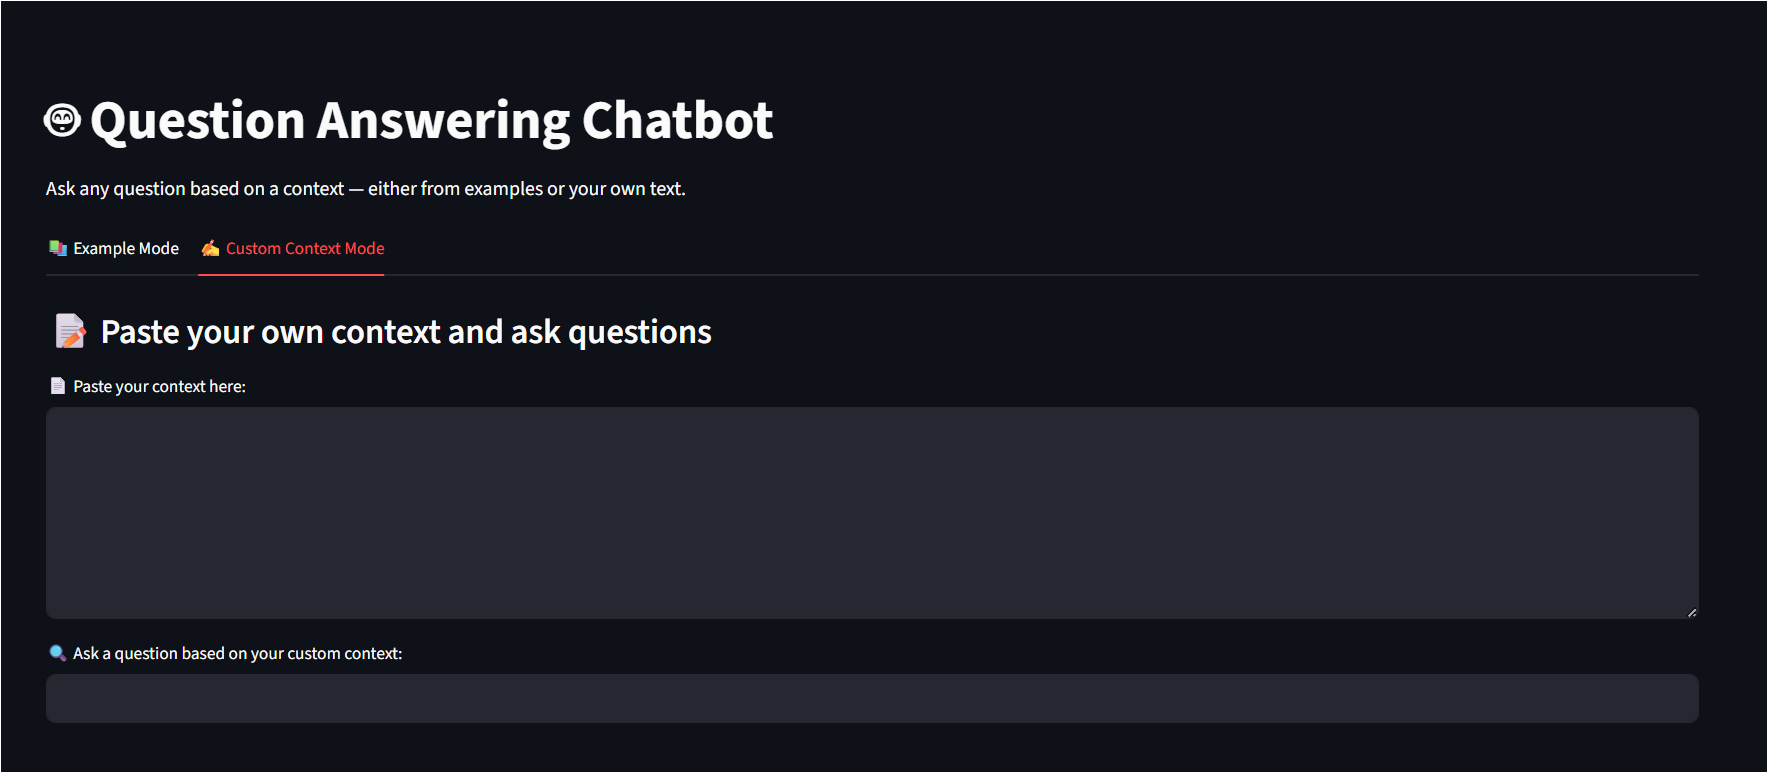

    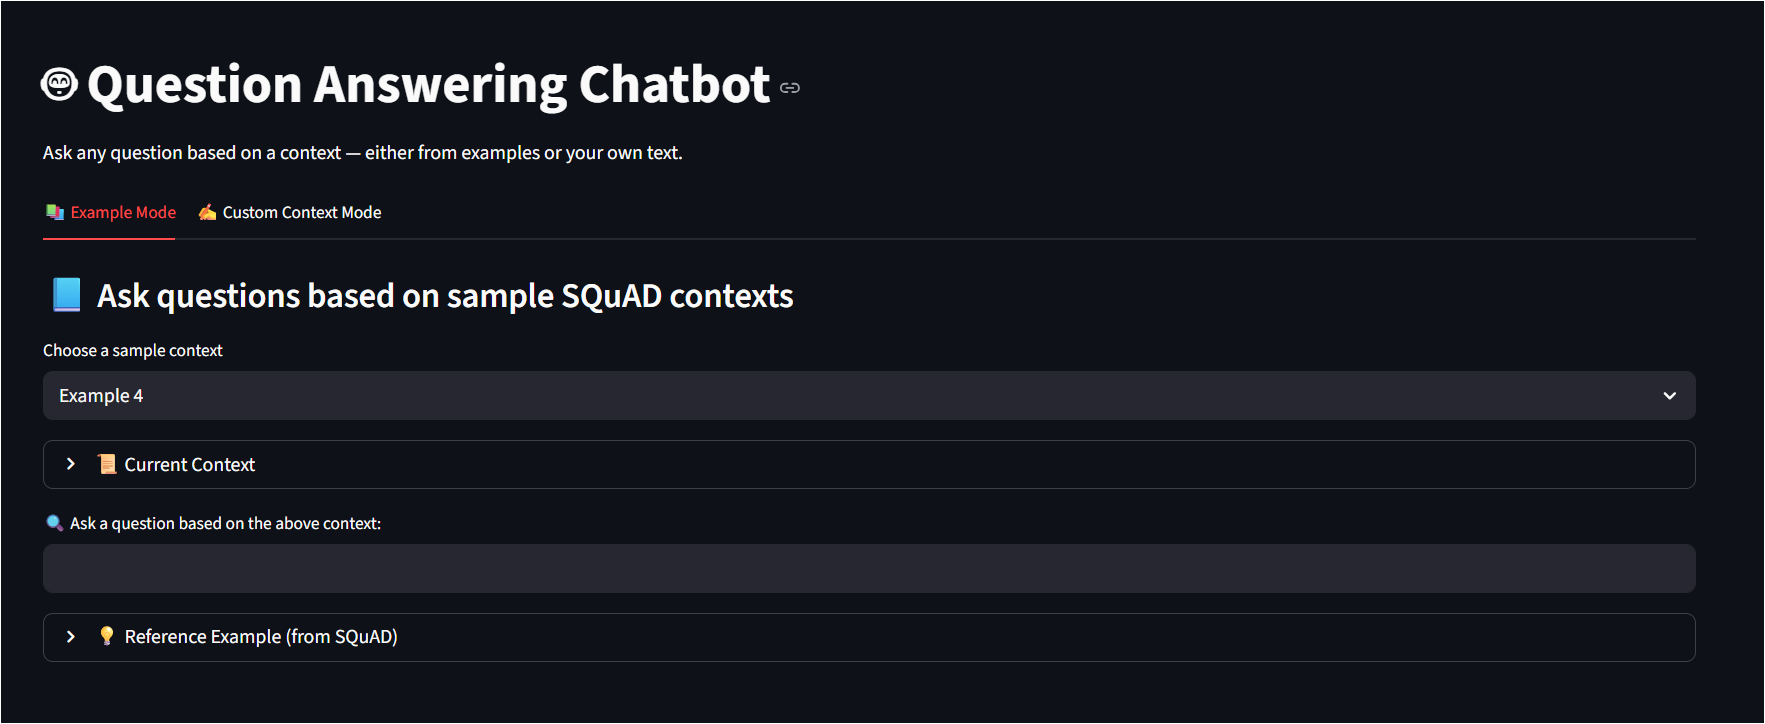